In [ ]:
%pip install -r ./../stellar_classification/requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [2]:
# Load dataset
data_path = './star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

display(star.head())


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u_g,g_r,r_i,i_z
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,...,6.543777e+18,GALAXY,0.634794,5812,56354,171,1.60352,1.88029,1.22928,0.37202
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,...,1.176014e+19,GALAXY,0.779136,10445,58158,427,1.94571,0.24744,1.41632,-0.44615
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,...,5.152200e+18,GALAXY,0.644195,4576,55592,299,2.59918,2.05413,1.26119,0.40030
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,...,1.030107e+19,GALAXY,0.932346,9149,58039,775,-1.63974,2.16494,1.10708,1.25444
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,...,6.891865e+18,GALAXY,0.116123,6121,56187,842,1.85690,1.08281,0.52036,0.43250


In [3]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


         obj_ID       alpha      delta         u        g         r         i  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573   

          z  run_ID  rerun_ID  ...   spec_obj_ID  class  redshift  plate  \
0  18.79371    3606       301  ...  6.543777e+18      0  0.634794   5812   

     MJD  fiber_ID      u_g      g_r      r_i      i_z  
0  56354       171  1.60352  1.88029  1.22928  0.37202  

[1 rows x 22 columns]
        alpha      delta         u        g         r         i         z  \
0  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573  18.79371   

   class  plate    MJD      u_g      g_r      r_i      i_z  
0      0   5812  56354  1.60352  1.88029  1.22928  0.37202  
Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)


In [4]:
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    batch_size=64
)

print("DataLoaders created.")

DataLoaders created.


In [6]:
# ============================================================
# Neural Network setup
# ============================================================

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

print("Input size:", input_size)
print("Number of classes:", num_classes)

Input size: 13
Number of classes: 3


In [7]:
# ============================================================
# Import experiment runner
# ============================================================

from stellar_classification.experiments.nn_runner import run_experiments

In [8]:
# ============================================================
# Run Neural Network Experiments
# ============================================================

results_df = run_experiments(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,

    input_size=input_size,
    num_classes=num_classes,

    model_types=[
        "SimpleNN",
        "MediumNN",
        "ComplexNN",
    ],

    learning_rates=[
        0.01,
        0.001,
        0.0001,
    ],

    epochs=15,
)


Training SimpleNN | lr=0.01
Epoch 1/15 | loss=0.4353 | train_acc=83.60% | val_acc=86.77%
Epoch 2/15 | loss=0.3900 | train_acc=85.24% | val_acc=86.39%
Epoch 3/15 | loss=0.3735 | train_acc=85.89% | val_acc=85.87%
Epoch 4/15 | loss=0.3661 | train_acc=86.24% | val_acc=86.40%
Epoch 5/15 | loss=0.3599 | train_acc=86.60% | val_acc=87.10%
Epoch 6/15 | loss=0.3565 | train_acc=86.70% | val_acc=87.12%
Epoch 7/15 | loss=0.3529 | train_acc=86.82% | val_acc=87.36%
Epoch 8/15 | loss=0.3509 | train_acc=86.92% | val_acc=86.24%
Epoch 9/15 | loss=0.3483 | train_acc=86.98% | val_acc=88.20%
Epoch 10/15 | loss=0.3499 | train_acc=86.99% | val_acc=87.78%
Epoch 11/15 | loss=0.3476 | train_acc=87.06% | val_acc=88.75%
Epoch 12/15 | loss=0.3452 | train_acc=87.12% | val_acc=87.58%
Epoch 13/15 | loss=0.3439 | train_acc=87.16% | val_acc=88.25%
Epoch 14/15 | loss=0.3432 | train_acc=87.23% | val_acc=88.53%
Epoch 15/15 | loss=0.3407 | train_acc=87.39% | val_acc=87.58%
✔ Done: SimpleNN | lr=0.01 | loss=0.3407 | train_a

In [9]:
# ============================================================
# Results
# ============================================================

display(results_df)

,model,learning_rate,trained_model,final_loss,final_train_acc,final_val_acc,train_accuracy,train_f1,val_accuracy,val_f1,test_accuracy,test_f1,history
3,MediumNN,0.0100,MediumNN(\n (net): Sequential(\n (0): Line...,0.299299,88.707849,89.850468,89.185011,0.891537,89.850468,0.870920,89.894287,0.871181,"{'train_loss': [0.39959887671054156, 0.3515872..."
4,MediumNN,0.0010,MediumNN(\n (net): Sequential(\n (0): Line...,0.280070,89.369486,89.078162,89.744620,0.897395,89.078162,0.864420,89.308211,0.866457,"{'train_loss': [0.4302152775488327, 0.36027302..."
7,ComplexNN,0.0010,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.197022,92.549880,89.127458,92.840506,0.928397,89.127458,0.863154,89.587555,0.868779,"{'train_loss': [0.3888868043590865, 0.33178688..."
6,ComplexNN,0.0100,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.304015,88.585209,88.727611,88.566658,0.885241,88.727611,0.858247,89.111026,0.862147,"{'train_loss': [0.41933390741766324, 0.3625542..."
8,ComplexNN,0.0001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.276741,89.568390,88.070329,89.101534,0.890943,88.070329,0.853991,88.541381,0.859504,"{'train_loss': [0.47007202957716915, 0.3673723..."
1,SimpleNN,0.0010,SimpleNN(\n (net): Sequential(\n (0): Line...,0.333214,87.584508,87.927918,87.671078,0.876348,87.927918,0.849405,88.459221,0.855214,"{'train_loss': [0.48928157152238455, 0.4173927..."
5,MediumNN,0.0001,MediumNN(\n (net): Sequential(\n (0): Line...,0.344539,86.909473,87.878622,87.108377,0.870696,87.878622,0.849174,88.349674,0.854028,"{'train_loss': [0.6289744699912867, 0.45103016..."
0,SimpleNN,0.0100,SimpleNN(\n (net): Sequential(\n (0): Line...,0.340728,87.385605,87.582845,87.069214,0.870038,87.582845,0.844540,87.703347,0.846303,"{'train_loss': [0.4353246839229575, 0.38998323..."
2,SimpleNN,0.0001,SimpleNN(\n (net): Sequential(\n (0): Line...,0.410700,84.733902,85.665772,84.731841,0.846675,85.665772,0.824637,86.038232,0.828131,"{'train_loss': [0.6988276190363268, 0.53010922..."


In [10]:
from stellar_classification.visualization.nn_plots import plot_training_history

In [11]:
best_simple = results_df[results_df["model"] == "SimpleNN"].iloc[0]
best_medium = results_df[results_df["model"] == "MediumNN"].iloc[0]
best_complex = results_df[results_df["model"] == "ComplexNN"].iloc[0]

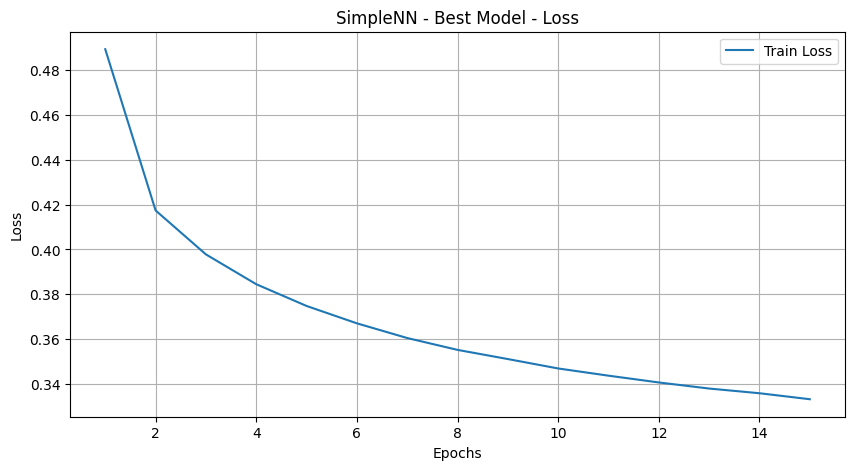

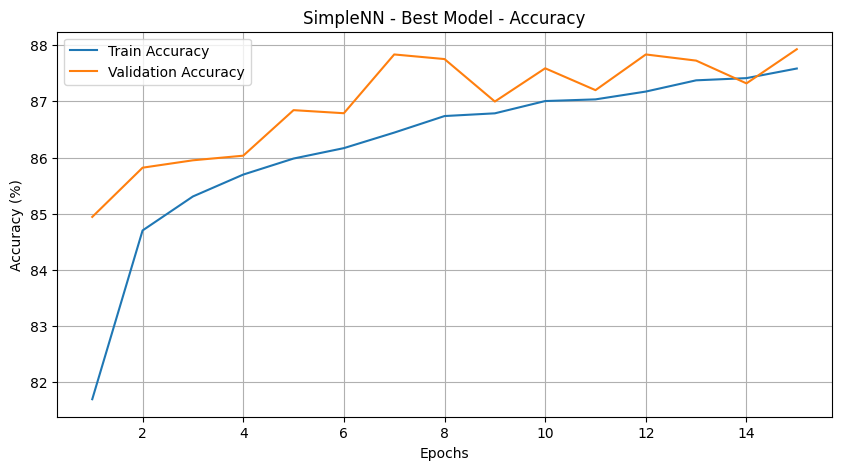

In [12]:
plot_training_history(best_simple["history"], title="SimpleNN - Best Model")

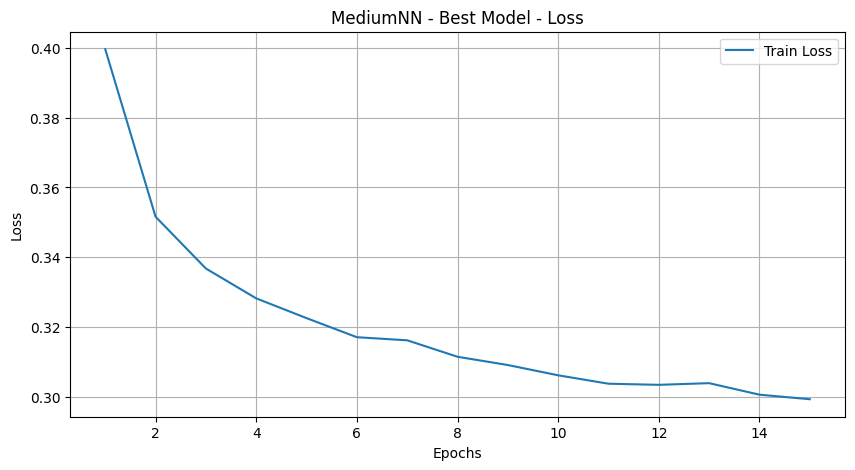

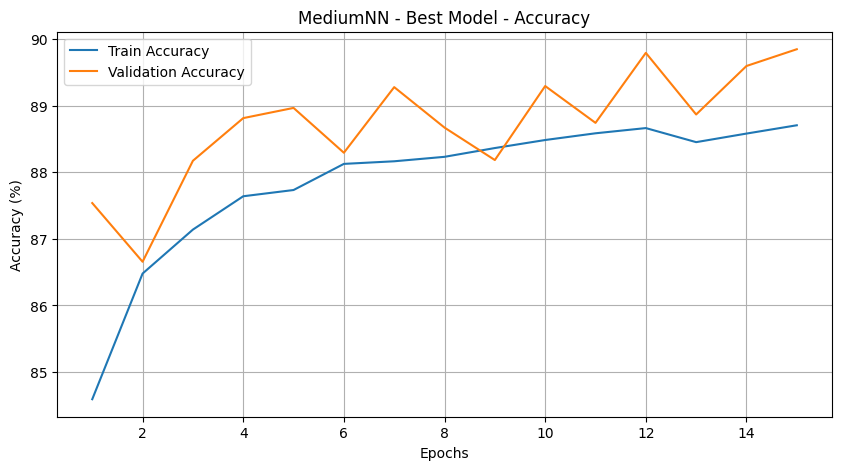

In [13]:
plot_training_history(best_medium["history"], title="MediumNN - Best Model")

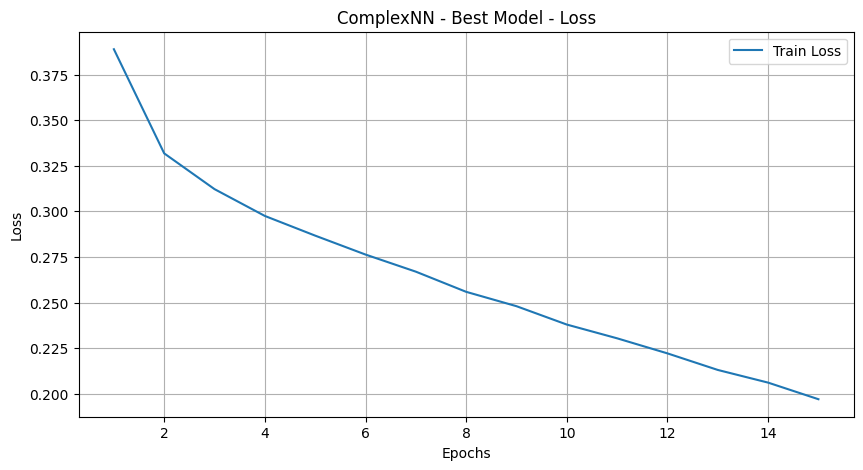

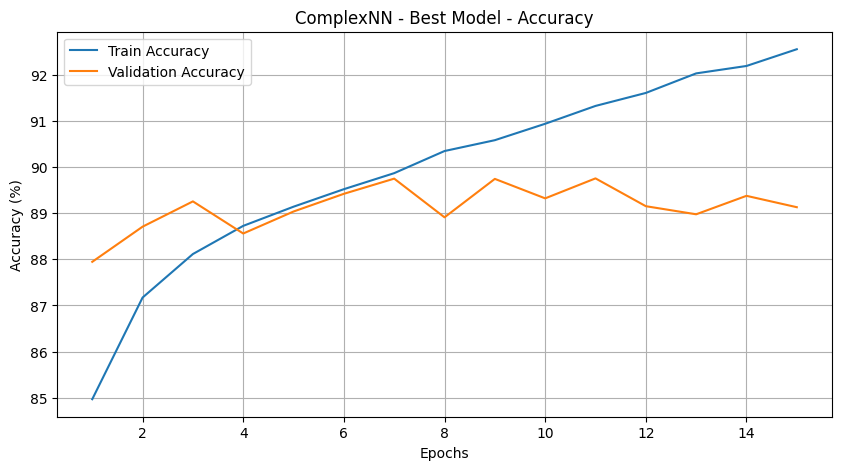

In [14]:
plot_training_history(best_complex["history"], title="ComplexNN - Best Model")

In [15]:
dropout_results = sc.experiments.nn_runner.run_dropout_ablation(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    input_size=input_size,
    num_classes=num_classes,
    results_df=results_df,
    dropout_values=(0.2, 0.3, 0.5),
    epochs=15,
)


Best configuration for MediumNN: lr=0.01 | val_f1=0.8709

Dropout test → MediumNN | lr=0.01 | dropout=0.2
Epoch 1/15 | loss=0.4426 | train_acc=83.10% | val_acc=87.60%
Epoch 2/15 | loss=0.4043 | train_acc=84.63% | val_acc=88.49%
Epoch 3/15 | loss=0.3950 | train_acc=84.85% | val_acc=88.26%
Epoch 4/15 | loss=0.3925 | train_acc=85.13% | val_acc=86.53%
Epoch 5/15 | loss=0.3865 | train_acc=85.40% | val_acc=87.10%
Epoch 6/15 | loss=0.3863 | train_acc=85.47% | val_acc=88.05%
Epoch 7/15 | loss=0.3830 | train_acc=85.50% | val_acc=87.96%
Epoch 8/15 | loss=0.3834 | train_acc=85.50% | val_acc=88.97%
Epoch 9/15 | loss=0.3805 | train_acc=85.74% | val_acc=88.72%
Epoch 10/15 | loss=0.3828 | train_acc=85.74% | val_acc=88.86%
Epoch 11/15 | loss=0.3782 | train_acc=85.90% | val_acc=88.78%
Epoch 12/15 | loss=0.3736 | train_acc=85.98% | val_acc=87.58%
Epoch 13/15 | loss=0.3741 | train_acc=85.99% | val_acc=88.85%
Epoch 14/15 | loss=0.3763 | train_acc=85.93% | val_acc=87.59%
Epoch 15/15 | loss=0.3714 | train_

In [16]:
dropout_results.sort_values(by="val_f1", ascending=False).head(10)

,model,learning_rate,dropout,trained_model,final_loss,final_train_acc,final_val_acc,val_accuracy,val_f1,test_accuracy,test_f1,history
4,ComplexNN,0.001,0.3,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.306077,88.598607,89.494440,89.494440,0.868014,89.943583,0.872608,"{'train_loss': [0.4447006504336862, 0.37750382..."
5,ComplexNN,0.001,0.5,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.354133,86.922871,89.439667,89.439667,0.866886,89.850468,0.870958,"{'train_loss': [0.505475067982331, 0.417468463..."
3,ComplexNN,0.001,0.2,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.280011,89.414832,89.111026,89.111026,0.864890,89.587555,0.869818,"{'train_loss': [0.4253232229596781, 0.36325751..."
1,MediumNN,0.010,0.3,MediumNN(\n (net): Sequential(\n (0): Line...,0.405945,84.947234,88.031988,88.031988,0.842583,88.272991,0.845860,"{'train_loss': [0.4682451653280145, 0.43023525..."
0,MediumNN,0.010,0.2,MediumNN(\n (net): Sequential(\n (0): Line...,0.371422,86.160236,86.941995,86.941995,0.842463,87.549981,0.849098,"{'train_loss': [0.442555620185859, 0.404270295..."
2,MediumNN,0.010,0.5,MediumNN(\n (net): Sequential(\n (0): Line...,0.486485,82.338816,87.484253,87.484253,0.833721,87.577368,0.835167,"{'train_loss': [0.532718741744462, 0.498838811..."


In [17]:
best_medium_dropout = dropout_results[dropout_results["model"] == "MediumNN"].iloc[0]
best_complex_dropout = dropout_results[dropout_results["model"] == "ComplexNN"].iloc[0]

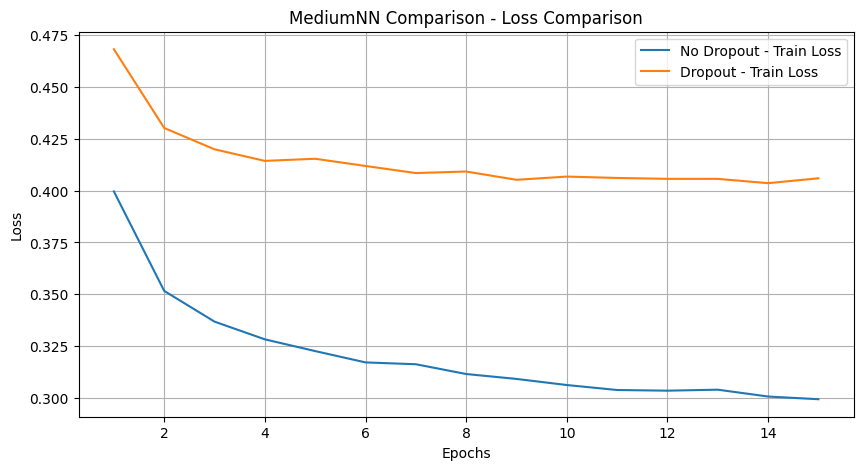

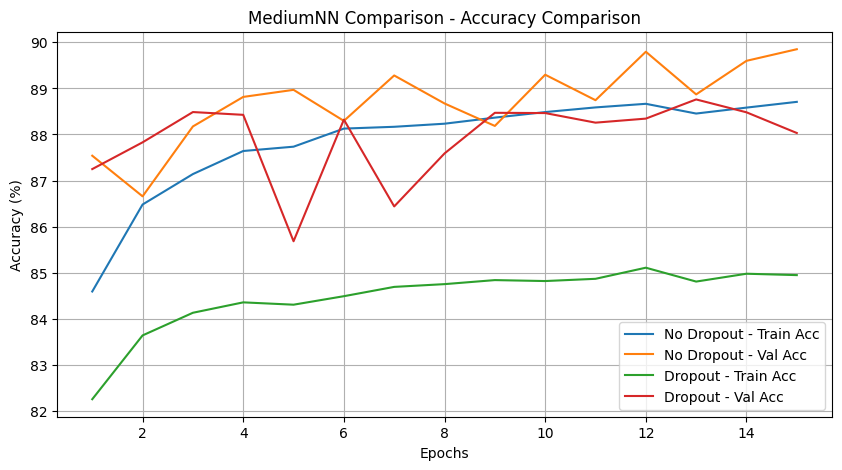

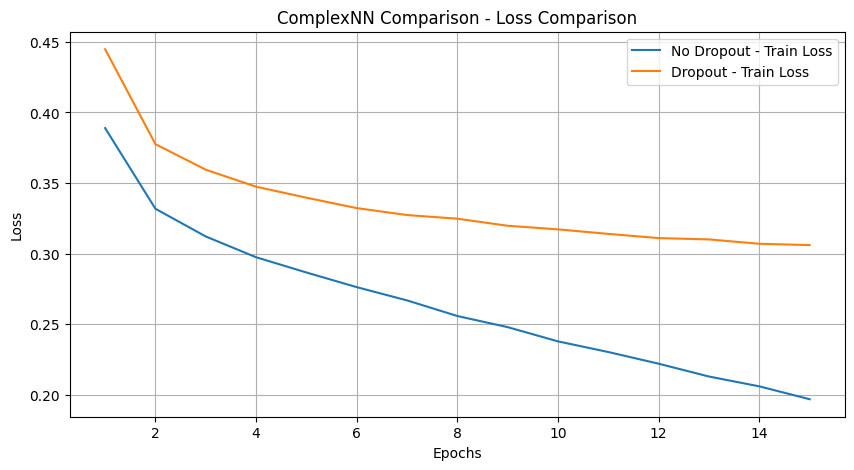

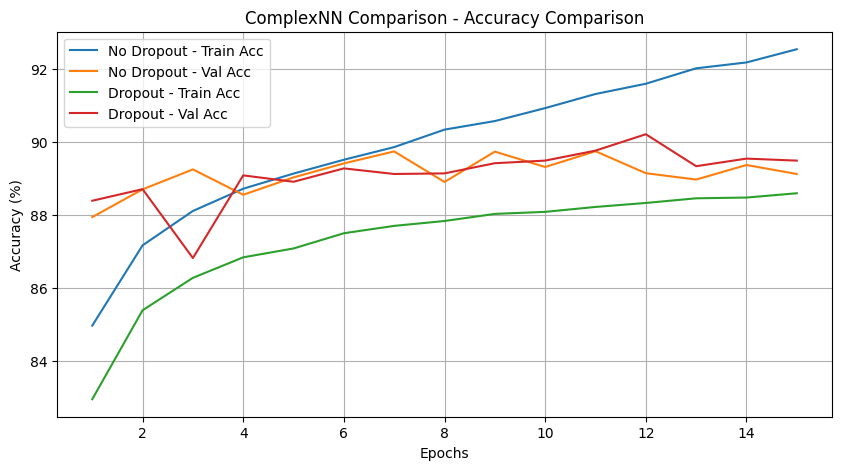

In [18]:
from stellar_classification.visualization.nn_plots import plot_dropout_comparison

plot_dropout_comparison(
    best_medium["history"],
    best_medium_dropout["history"],
    title="MediumNN Comparison"
)

plot_dropout_comparison(
    best_complex["history"],
    best_complex_dropout["history"],
    title="ComplexNN Comparison"
)

In [19]:
from stellar_classification.visualization.model_selection import get_final_candidates

final_sorted = get_final_candidates(
    results_df=results_df,
    dropout_results=dropout_results,
    top_k=3
)

display(final_sorted)

,model,learning_rate,trained_model,final_loss,final_train_acc,final_val_acc,train_accuracy,train_f1,val_accuracy,val_f1,test_accuracy,test_f1,history,dropout
0,MediumNN,0.010,MediumNN(\n (net): Sequential(\n (0): Line...,0.299299,88.707849,89.850468,89.185011,0.891537,89.850468,0.870920,89.894287,0.871181,"{'train_loss': [0.39959887671054156, 0.3515872...",NaN
3,ComplexNN,0.001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.306077,88.598607,89.494440,NaN,NaN,89.494440,0.868014,89.943583,0.872608,"{'train_loss': [0.4447006504336862, 0.37750382...",0.3
4,ComplexNN,0.001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.354133,86.922871,89.439667,NaN,NaN,89.439667,0.866886,89.850468,0.870958,"{'train_loss': [0.505475067982331, 0.417468463...",0.5
5,ComplexNN,0.001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.280011,89.414832,89.111026,NaN,NaN,89.111026,0.864890,89.587555,0.869818,"{'train_loss': [0.4253232229596781, 0.36325751...",0.2
1,MediumNN,0.001,MediumNN(\n (net): Sequential(\n (0): Line...,0.280070,89.369486,89.078162,89.744620,0.897395,89.078162,0.864420,89.308211,0.866457,"{'train_loss': [0.4302152775488327, 0.36027302...",NaN
2,ComplexNN,0.001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.197022,92.549880,89.127458,92.840506,0.928397,89.127458,0.863154,89.587555,0.868779,"{'train_loss': [0.3888868043590865, 0.33178688...",NaN



MediumNN:
  Accuracy  : 89.89%
  Precision: 0.8694
  Recall   : 0.8739
  F1       : 0.8712
  Confusion Matrix:
[[10134   344   303]
 [  251  3060   237]
 [  310   400  3218]]


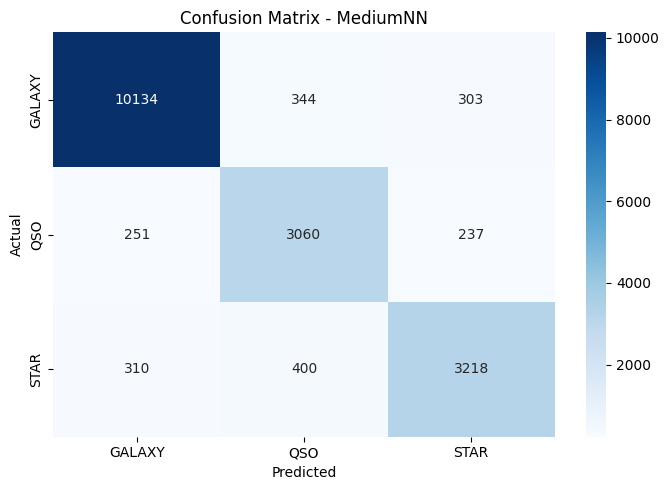

In [20]:
from stellar_classification.experiments.nn_runner import device
from stellar_classification.inference.predictor import evaluate_neural

# Miglior modello assoluto
best_model_row = final_sorted.iloc[0]

best_metrics = evaluate_neural(
    test_loader=test_loader,
    model=best_model_row["trained_model"],
    device=device,
    model_name=f"{best_model_row['model']}"
)

# Stampa metriche
sc.print_metrics(best_metrics)

# Confusion matrix

class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(
    best_metrics["confusion_matrix"],
    class_names=class_names,
    title=f"Confusion Matrix - {best_model_row['model']}"
)

1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2257


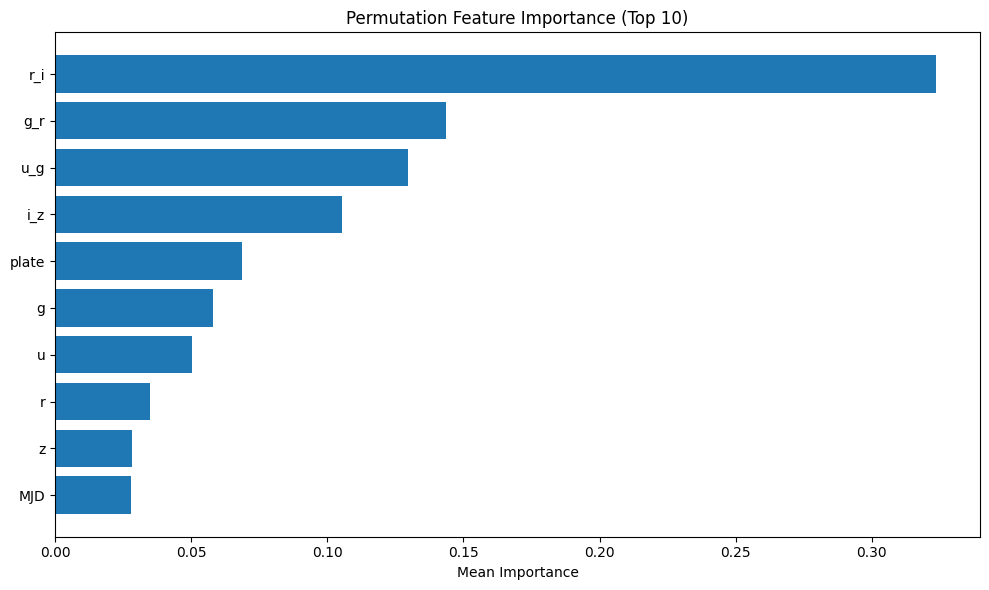

In [21]:
from stellar_classification.utils.wrapper import TorchModelWrapper

from stellar_classification.inference.predictor import compute_permutation_importance


wrapped_model = TorchModelWrapper(best_model_row["trained_model"], device)

imp = compute_permutation_importance(
    wrapped_model,
    X_test,
    y_test,
    feature_names=feature_names,
    n_jobs=1
)

sc.plot_permutation_importance(imp, top_n=10)

In [22]:
from stellar_classification.experiments.feature_ablation import run_feature_ablation

best_model_row = final_sorted.iloc[0]

importance_scores = imp

ablation_results = run_feature_ablation(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    feature_names=feature_names,
    best_model_row=best_model_row,
    input_size=X_train.shape[1],
    num_classes=num_classes,
    device=device,
    importance_scores=importance_scores,
    epochs=15
)

ablation_results


Best model: MediumNN | lr=0.01

Training with top-1 features: ['r_i']
Epoch 1/15 | loss=0.8130 | train_acc=60.78% | val_acc=72.36%
Epoch 2/15 | loss=0.8054 | train_acc=61.98% | val_acc=71.00%
Epoch 3/15 | loss=0.8038 | train_acc=62.11% | val_acc=70.13%
Epoch 4/15 | loss=0.8030 | train_acc=62.02% | val_acc=70.55%
Epoch 5/15 | loss=0.8026 | train_acc=62.13% | val_acc=72.43%
Epoch 6/15 | loss=0.8023 | train_acc=62.17% | val_acc=71.94%
Epoch 7/15 | loss=0.8018 | train_acc=62.26% | val_acc=71.62%
Epoch 8/15 | loss=0.8016 | train_acc=62.28% | val_acc=71.44%
Epoch 9/15 | loss=0.8010 | train_acc=62.35% | val_acc=70.57%
Epoch 10/15 | loss=0.8009 | train_acc=62.20% | val_acc=72.02%
Epoch 11/15 | loss=0.8013 | train_acc=62.33% | val_acc=71.59%
Epoch 12/15 | loss=0.8017 | train_acc=62.37% | val_acc=71.69%
Epoch 13/15 | loss=0.8008 | train_acc=62.21% | val_acc=72.13%
Epoch 14/15 | loss=0.8009 | train_acc=62.31% | val_acc=71.15%
Epoch 15/15 | loss=0.8009 | train_acc=62.33% | val_acc=71.64%

Trainin

,n_features,features,val_f1,test_f1
0,1,[r_i],0.615306,0.616169
1,2,"[r_i, g_r]",0.758451,0.756481
2,3,"[r_i, g_r, u_g]",0.812355,0.815607
3,4,"[r_i, g_r, u_g, i_z]",0.823958,0.826336
4,5,"[r_i, g_r, u_g, i_z, plate]",0.853038,0.853000
5,6,"[r_i, g_r, u_g, i_z, plate, g]",0.859753,0.865673
6,7,"[r_i, g_r, u_g, i_z, plate, g, u]",0.868279,0.867719
7,8,"[r_i, g_r, u_g, i_z, plate, g, u, r]",0.858764,0.864422
8,9,"[r_i, g_r, u_g, i_z, plate, g, u, r, z]",0.860021,0.863691
9,10,"[r_i, g_r, u_g, i_z, plate, g, u, r, z, MJD]",0.856004,0.863945


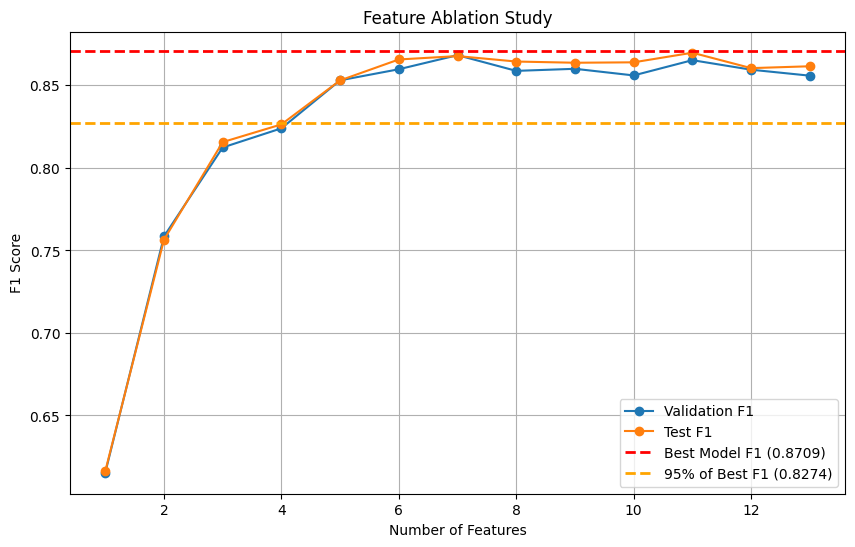

In [23]:
from stellar_classification.visualization.model_selection import plot_feature_ablation

best_val_f1 = final_sorted.iloc[0]["val_f1"]

plot_feature_ablation(
    ablation_results,
    best_val_f1=best_val_f1
)

In [24]:
from stellar_classification.experiments.feature_ablation import (
    get_feature_subset_threshold
)

best_subset = get_feature_subset_threshold(
    ablation_results,
    best_val_f1=best_model_row["val_f1"],
    threshold=0.95,
)

if best_subset is not None:
    print("\n===== 95% FEATURE SUBSET =====")
    print(f"Target F1       : {0.95 * best_model_row['val_f1']:.4f}")
    print(f"Reached F1      : {best_subset['val_f1']:.4f}")
    print(f"N. features     : {best_subset['n_features']}")
    print("\nSelected features:")
    for f in best_subset["features"]:
        print(f" - {f}")
else:
    print("No subset reached the required threshold.")


===== 95% FEATURE SUBSET =====
Target F1       : 0.8274
Reached F1      : 0.8530
N. features     : 5

Selected features:
 - r_i
 - g_r
 - u_g
 - i_z
 - plate


In [25]:
print(
    f"Relative performance: "
    f"{100 * best_subset['val_f1'] / best_model_row['val_f1']:.2f}%"
)

Relative performance: 97.95%


priossima cosa da fare: pensare di aggiungere stop a feature ablation, aggiungere PCA. 